# 第 3 讲：极点配置——从期望动态到反馈增益

第 2 讲通过试增益找到了可用的状态反馈。本讲学习一种系统方法：先描述“希望系统以多快、怎样的形状收敛”，再由算法反推出反馈增益。

本讲目标：

1. 把闭环特征值理解为系统的时间尺度与振荡形式；
2. 理解可控性为什么是极点配置的前提；
3. 使用项目中的 `NominalBikeController`；
4. 比较慢、中、快三组极点；
5. 实践随前进速度变化的增益调度。

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

project_root = Path.cwd()
if not (project_root / "nominal_bike_control").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from nominal_bike_control import NominalBikeController, ScaleBikeModel

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-bright")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((name for name in ["Arial Unicode MS", "PingFang HK", "Noto Sans CJK SC", "SimHei"] if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({"font.sans-serif": [chinese_font], "axes.unicode_minus": False})


ImportError: cannot import name 'ScaleBikeModel' from 'nominal_bike_control' (/Users/toutou/Desktop/jump_orange_mujocosim/nominal_bike_control/__init__.py)

## 1. 反馈怎样改变系统

标称模型为

$$\dot x=Ax+Bu$$

取目标为零并采用 $u=-Kx$ 后：

$$\dot x=(A-BK)x$$

所以控制器不是直接修改物理参数，而是通过反馈让系统表现得像一个新矩阵 $A_{cl}=A-BK$。闭环极点就是 $A-BK$ 的特征值。

对于实负极点 $p$，典型时间常数约为 $\tau=1/|p|$，常用的 2% 调节时间粗略为 $4/|p|$。例如极点 -5 对应时间常数约 0.2 s、调节时间约 0.8 s。极点更靠左通常更快，但也常常要求更大的控制量，并更敏感于噪声、延迟和未建模动态。

In [ ]:
control_dt = 0.02  # 50 Hz
bike = ScaleBikeModel(dt=control_dt, track_roll=False)
bike.updateSysParam(2.0, min_forw_vel=1.0)
A, B = bike.A, bike.Bu
print("A =\n", A)
print("B =\n", B)


A =
 [[ 0.      0.      0.    ]
 [ 0.      0.      1.    ]
 [37.9113 25.1969  0.    ]]
B =
 [[1.    ]
 [0.    ]
 [2.2178]]


## 2. 可控性：一个输入真的能影响三个状态吗？

自行车只有一个外环输入 $u=\dot\delta$，却有三个状态。能否任意配置三个极点，要看输入的影响能否经过动力学传播到所有状态。连续时间线性系统的可控性矩阵是

$$\mathcal C=[B,\;AB,\;A^2B]$$

如果它的秩等于状态数 3，系统完全可控。秩可以理解为这些列向量提供了多少个独立方向。

In [ ]:
controllability = np.hstack([B, A @ B, A @ A @ B])
print("可控性矩阵 =\n", controllability)
print("秩 =", np.linalg.matrix_rank(controllability), "/ 3")
assert np.linalg.matrix_rank(controllability) == 3


可控性矩阵 =
 [[ 1.      0.      0.    ]
 [ 0.      2.2178 37.9113]
 [ 2.2178 37.9113 55.8821]]
秩 = 3 / 3


## 3. 用控制包配置极点

项目中的无扰动观测控制包直接使用完整测量状态，控制律为

$$u=u_e+K(x_e-x)$$

当参考为零时，$x_e=0,u_e=0$，就退化成 $u=-Kx$。`place_multiple_poles` 会把三个极点都放在 `wc`；当前单输入模型使用 Ackermann 公式，因此允许重复极点。

In [ ]:
pole_controller = NominalBikeController(
    bike.sys,
    method="place_multiple_poles",
    wc=-5.0,
    u_min=-10.0,
    u_max=10.0,
)
print("反馈增益 K =", pole_controller.K)
print("实际闭环极点 =", pole_controller.closed_loop_poles)
print("直接验证 eig(A-BK) =", np.linalg.eigvals(A - B @ pole_controller.K))


反馈增益 K = [[10.469  10.2552  2.043 ]]
实际闭环极点 = [-5.+0.j -5.-0.j -5.+0.j]
直接验证 eig(A-BK) = [-5.+0.j -5.-0.j -5.+0.j]


In [ ]:
def simulate_controller(controller, A, B, x0, duration=2.0,
                        plant_dt=0.001, control_dt=0.02):
    time = np.arange(0.0, duration + plant_dt, plant_dt)
    states = np.zeros((time.size, 3))
    controls = np.zeros(time.size)
    states[0] = x0
    update_every = int(round(control_dt / plant_dt))
    held_control = 0.0
    for k in range(time.size - 1):
        if k % update_every == 0:
            held_control = float(controller.step([[0.0]], states[k].reshape(3, 1))[0, 0])
        controls[k] = held_control
        states[k + 1] = states[k] + (A @ states[k] + B[:, 0] * held_control) * plant_dt
    controls[-1] = held_control
    return time, states, controls


## 4. 极点越快越好吗？

下面比较 -2、-5、-8 三组重复极点。所有控制器从相同的 $3^\circ$ 初始倾角开始，采用相同 50 Hz 采样和 $\pm10$ rad/s 限幅。观察滚转收敛速度的同时，也要看控制峰值。

p=-2.0: max|u|=0.161 rad/s, max|roll|=5.834 deg
p=-5.0: max|u|=0.537 rad/s, max|roll|=3.000 deg
p=-8.0: max|u|=1.204 rad/s, max|roll|=3.000 deg


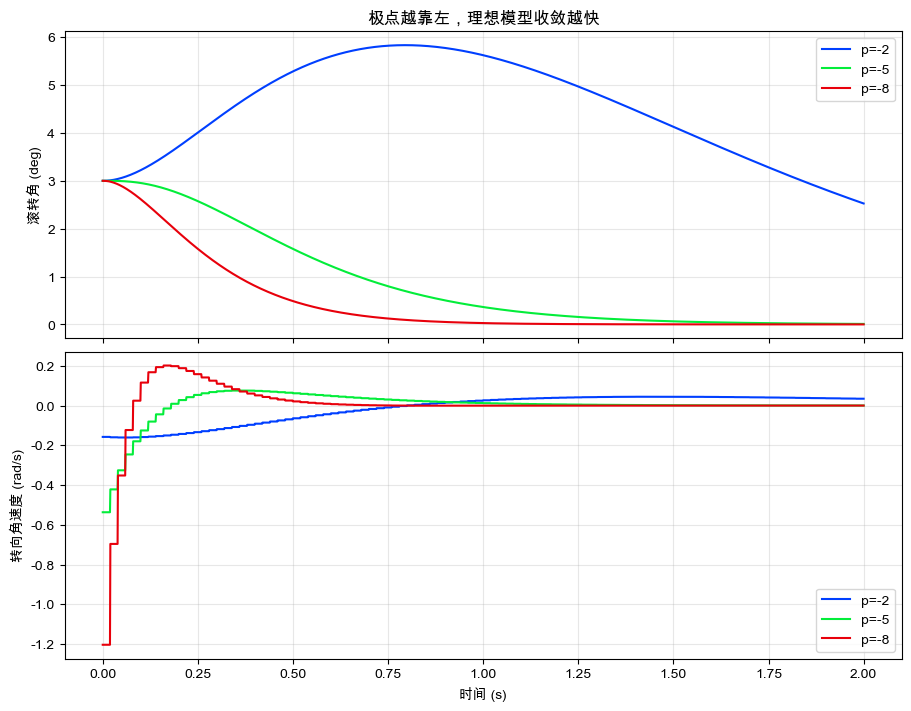

In [ ]:
pole_sets = [-2.0, -5.0, -8.0]
comparison = {}
for pole in pole_sets:
    controller = NominalBikeController(
        bike.sys, method="place_multiple_poles", wc=pole,
        u_min=-10.0, u_max=10.0
    )
    comparison[pole] = simulate_controller(
        controller, A, B, np.deg2rad([0.0, 3.0, 0.0])
    )

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)
for pole, (time, states, controls) in comparison.items():
    axes[0].plot(time, np.rad2deg(states[:, 1]), label=f"p={pole:g}")
    axes[1].plot(time, controls, label=f"p={pole:g}")
    print(f"p={pole:4.1f}: max|u|={np.max(np.abs(controls)):.3f} rad/s, "
          f"max|roll|={np.max(np.abs(np.rad2deg(states[:, 1]))):.3f} deg")
axes[0].set_ylabel("滚转角 (deg)")
axes[0].set_title("极点越靠左，理想模型收敛越快")
axes[1].set_ylabel("转向角速度 (rad/s)")
axes[1].set_xlabel("时间 (s)")
for axis in axes:
    axis.grid(True, alpha=0.3)
    axis.legend()
plt.show()


## 5. 不同极点的角色

重复极点容易理解，但工程上常用不同极点。较快的极点可以处理不希望出现的内部模态，较慢的主导极点决定肉眼看到的整体响应。下面配置 `[-3, -5, -7]`。

In [ ]:
distinct_controller = NominalBikeController(
    bike.sys,
    method="place_distinct_poles",
    poles_ctr=[-3.0, -5.0, -7.0],
    u_min=-10.0, u_max=10.0,
)
print("K =", distinct_controller.K)
print("闭环极点 =", distinct_controller.closed_loop_poles)


K = [[10.6502  9.848   1.9613]]
闭环极点 = [-7. -5. -3.]


## 6. 增益调度

矩阵中的转向耦合随速度变化。若仍使用同一个 $K$，闭环极点会随速度漂移。项目采用的办法是每个控制周期根据当前前进速度更新 $A,B$，然后重新计算 $K$。这不是非线性控制器的完整理论，而是一种简单实用的线性参数变化控制。

In [ ]:
scheduled_controller = NominalBikeController(
    bike.sys, method="place_multiple_poles", wc=-5.0
)
print(" speed | K_delta   K_roll   K_roll_rate | closed-loop poles")
print("-------+----------------------------------+------------------")
for speed in [1.0, 1.5, 2.0, 2.7, 3.5]:
    bike.updateSysParam(speed, min_forw_vel=1.0)
    scheduled_controller.updateSysAndGain(bike.sys)
    gains = scheduled_controller.K[0]
    print(f" {speed:5.1f} | {gains[0]:7.3f} {gains[1]:8.3f} {gains[2]:11.3f} | "
          f"{np.real(scheduled_controller.closed_loop_poles)}")


 speed | K_delta   K_roll   K_roll_rate | closed-loop poles
-------+----------------------------------+------------------
   1.0 |   7.614   33.432       6.660 | [-5. -5. -5.]
   1.5 |   9.384   16.949       3.377 | [-5. -5. -5.]
   2.0 |  10.469   10.255       2.043 | [-5. -5. -5.]
   2.7 |  11.434    5.979       1.191 | [-5. -5. -5.]
   3.5 |  12.132    3.709       0.739 | [-5. -5. -5.]


## 7. 非零参考不是把所有状态设成同一个数

如果希望保持一个非零转向角，稳态时车身通常需要相应倾斜。这里不符合动力学的是手工指定的 $[\delta_r,0,0]^T$，不是控制包。控制包会通过 `solve_equilibrium` 求解并验证

$$Ax_e+Bu_e=0,\qquad C_ox_e=y_r$$

得到一致的平衡点。若使用 `stepWithStateReference` 直接传入完整状态，控制包也会检查稳态残差；不满足动力学时会抛出 `ValueError`。

In [ ]:
bike.updateSysParam(2.0, min_forw_vel=1.0)
scheduled_controller.updateSysAndGain(bike.sys)
reference = np.deg2rad([[5.0]])
equilibrium = scheduled_controller.solve_equilibrium(reference)
x_eq, u_eq = equilibrium.state, equilibrium.control
print("5 deg 转向对应的平衡状态 [steer, roll, roll_rate] (deg)：")
print(np.rad2deg(x_eq[:, 0]))
print("平衡输入 u_eq (rad/s)：", u_eq[:, 0])
print("动力学残差：", equilibrium.residual_norm)

naive_state_reference = np.deg2rad([[5.0], [0.0], [0.0]])
try:
    scheduled_controller.validate_state_reference(naive_state_reference)
except ValueError as error:
    print("直接使用 [5 deg, 0, 0] 被拒绝：", error)


5 deg 转向对应的平衡状态 [steer, roll, roll_rate] (deg)：
[ 5.    -7.523  0.   ]
平衡输入 u_eq (rad/s)： [0.]
动力学残差： 8.169805838888548e-16


## 练习

1. 根据 $4/|p|$ 预测三组极点的调节时间，再从曲线上测量并比较。
2. 把控制限幅降到 1 rad/s，重新比较 -2、-5、-8；“最快极点”还是最快吗？
3. 在 1 m/s 设计固定增益，不再调度，然后把同一个增益用于 3.5 m/s，计算闭环极点。
4. 尝试不同的三实极点，也尝试一对共轭复极点，例如 `[-4, -3+3j, -3-3j]`，观察振荡。
5. 极点配置直接规定动态，却没有明确回答“状态误差”和“控制能量”谁更重要。第 4 讲用 LQR 表达这种权衡。